# 1). Import libraries

In [52]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

warnings.simplefilter(action="ignore")

# 2) Prepare data

In [12]:
df=pd.read_csv("/workspaces/Time-Series_Modelling-Air_Quality_in_Nairobi-/data/clean_p2_readings.csv")
df.set_index("timestamp", inplace=True)
df.head()
df.shape
#Turn into a series
y=df.squeeze()
y.shape


(2927,)

# 3). Explore

Text(0.5, 0, 'Lag [Hours]')

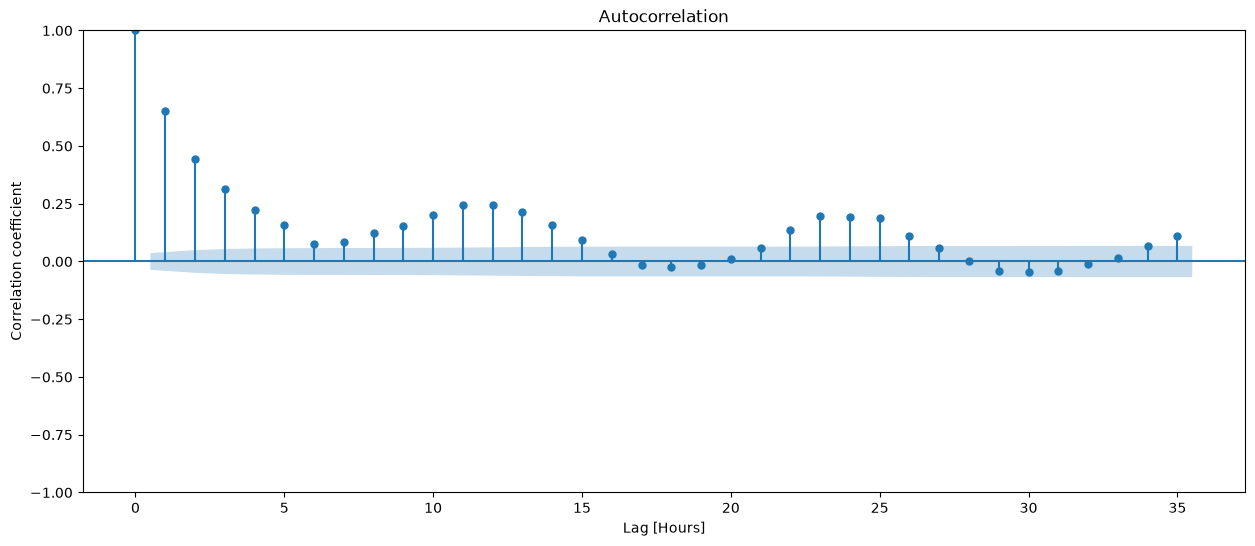

In [15]:
# Create autocorrelation function (ACF) plot
fig, ax=plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
plt.ylabel("Correlation coefficient")
plt.xlabel("Lag [Hours]")

Text(0.5, 0, 'Lag [Hours]')

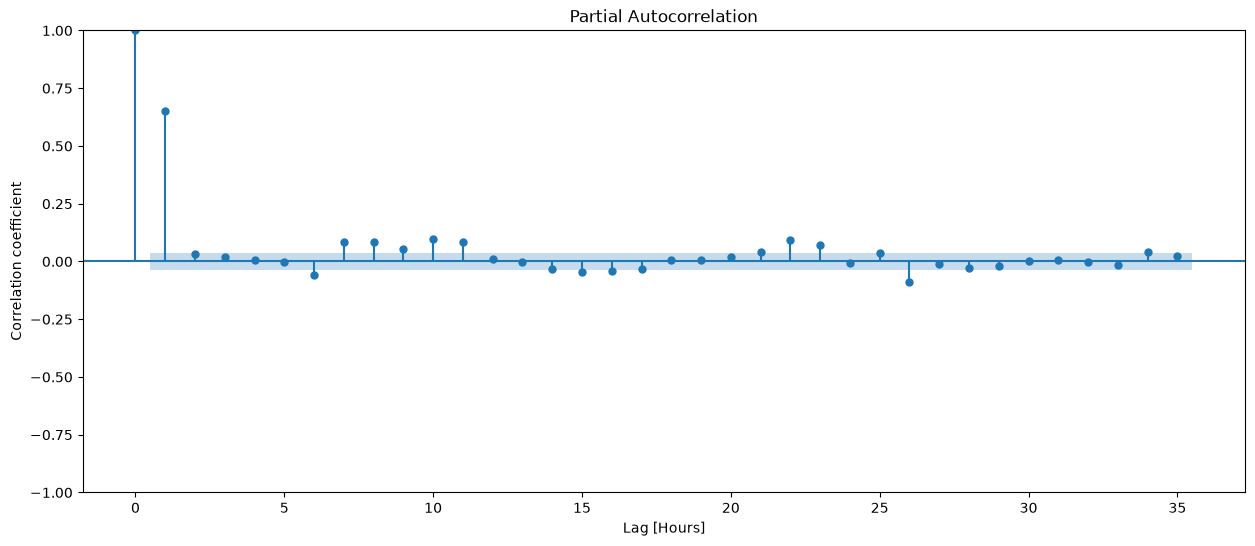

In [16]:
# Create partialautocorrelation function (PACF) plot
fig, ax=plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
plt.ylabel("Correlation coefficient")
plt.xlabel("Lag [Hours]")

In [24]:
# Split
cutoff=int(len(y)*0.95)
y_train=y.iloc[:cutoff]
y_test=y.iloc[cutoff:]
len(y_train)
len(y_test)


147

In [25]:
# Baseline
y_mean=y.mean()
y_pred_baseline=[y_mean]*len(y)
mae_baseline=mean_absolute_error(y, y_pred_baseline)
print(f"MAE Baseline: {mae_baseline}")


MAE Baseline: 3.653606224417101


In [31]:
# Train
model=AutoReg(y_train, lags=26).fit()
# Generate predictions
model.predict().isna().sum() #26 equivalent to our lag
y_pred=model.predict().dropna()
y_train_mae=mean_absolute_error(y_train.iloc[26:], y_pred)
print(f"Training MAE: {y_train_mae}")

Training MAE: 2.281544150838417


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Text(0.5, 0, 'Residuals')

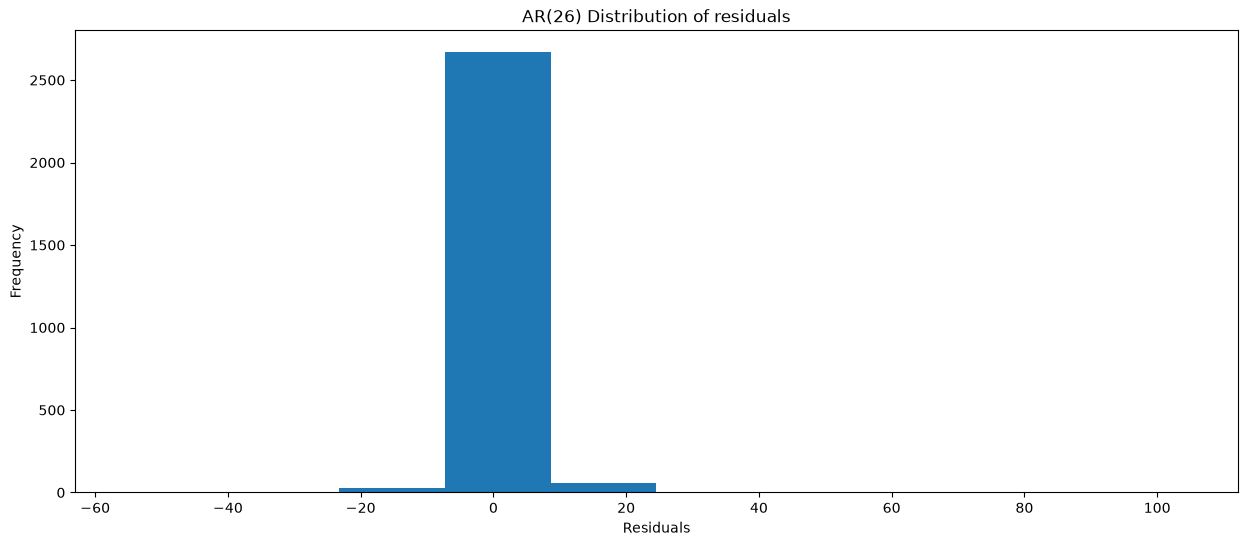

In [35]:
# Generate and plot residuals to ensure they are normally distributed
y_pred_resid=model.resid
fig, ax=plt.subplots(figsize=(15,6))
y_pred_resid.plot(kind="hist", ax=ax)
plt.title("AR(26) Distribution of residuals")
plt.xlabel("Residuals")

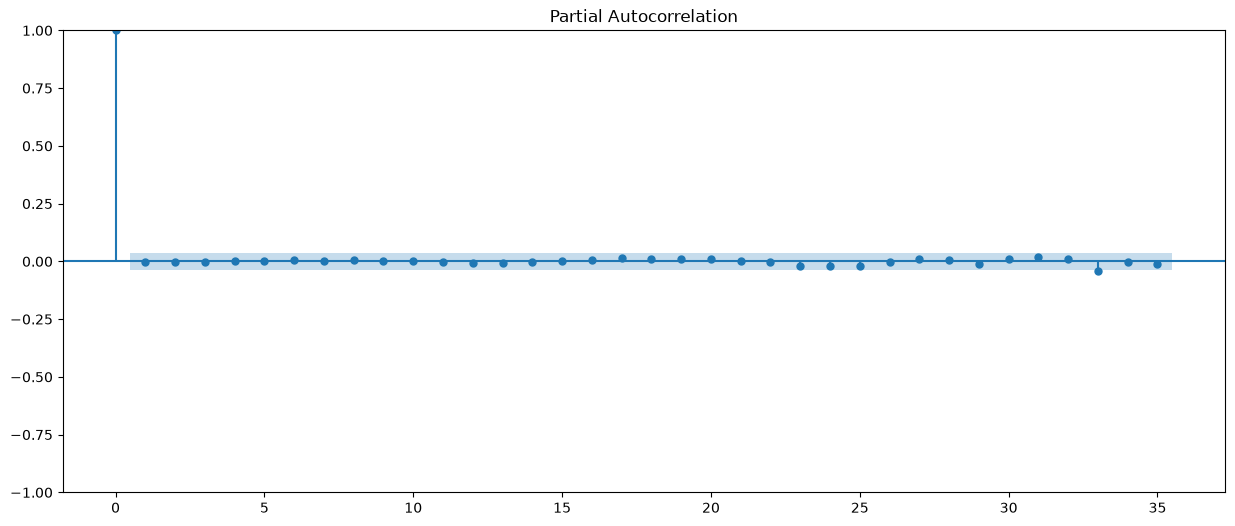

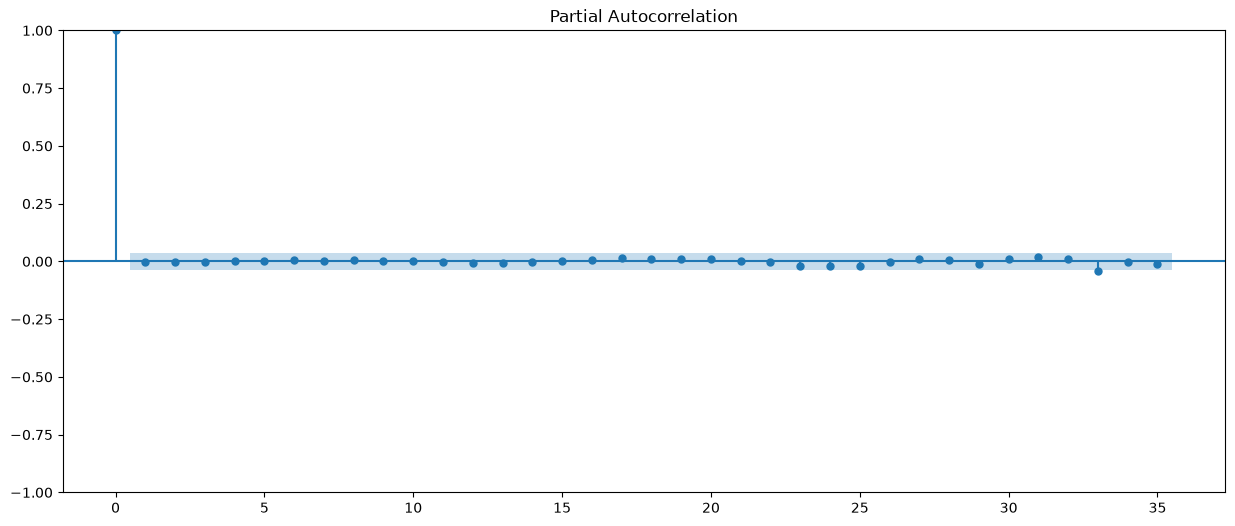

In [ ]:
fig, ax=plt.subplots(figsize=(15,6))
plot_pacf(y_pred_resid, ax=ax) # The plot indicates there is no signal left in our residuals to predict p2 readings

In [38]:
# Evaluate
y_pred_test=model.predict(y_test.index.min(), y_test.index.max())
y_test_mae=mean_absolute_error(y_test, y_pred_test)
print(f"y_test MAE: {y_test_mae}")

y_test MAE: 3.0160325090818088


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [ ]:
# Plot out
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred": y_pred_test}, index=y_test.index
)
fig = px.line(df_pred_test, labels={"value": "P2"})
fig.show()
# A pretty ugly model

In [55]:

y_pred_wfv = []
history = y_test.copy()

for i in range(len(y_test)):
    model = AutoReg(history, lags=26).fit()
    next_pred = model.forecast()   
    y_pred_wfv.append(next_pred.iloc[0])
    history = pd.concat([history, pd.Series([y_test.iloc[i]], index=[y_test.index[i]])])

y_pred_wfv = pd.Series(y_pred_wfv, index=y_test.index)
y_pred_wfv

y_pred_wfv_mae=mean_absolute_error(y_test, y_pred_wfv)
print(f"Walk Forward Validation MAE: {y_pred_wfv_mae}")

Walk Forward Validation MAE: 1.464778620834728


In [56]:
print(model.params)

const    1.044670
y.L1     0.788099
y.L2    -0.136515
y.L3    -0.010345
y.L4     0.144504
y.L5    -0.088610
y.L6     0.022320
y.L7     0.023147
y.L8     0.001072
y.L9     0.016980
y.L10   -0.016239
y.L11    0.171560
y.L12   -0.026957
y.L13    0.053085
y.L14   -0.101746
y.L15    0.001351
y.L16    0.131927
y.L17   -0.164071
y.L18   -0.074552
y.L19    0.050246
y.L20   -0.009749
y.L21    0.010631
y.L22    0.026988
y.L23    0.055370
y.L24   -0.020583
y.L25    0.079268
y.L26   -0.080621
dtype: float64


In [ ]:
# Plot out
df_wf_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred_wfv": y_pred_wfv}, index=y_test.index
)
fig = px.line(df_wf_pred_test, labels={"value": "PM2.5"})
fig.show()